# 1. Introduction to Neural Networks

In [ ]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/deeplearning.udea/main/content/init.py
import init; init.init(force_download=False); 

Artificial Neural Networks (ANNs) are bioinspired algorithms that address a wide range of problems in machine learning. ANNs aim to emulate the behavior and learning capabilities of biological neural networks; they are built from a structure composed of many basic units (neurons) called **perceptrons**, which, in conjunction, can solve complex problems. 

ANNs can be used for various learning paradigms, but in most common scenarios, they are employed as a mapping $x \rightarrow y$ from an input space $x \in \mathcal{X}$ to an output space $y \in \mathcal {Y}$. Depending on the application, $x$ and $y$ can be samples from different information modalities such as vectors, matrices, images, videos, or audio signals. Therefore, the study of neural networks involves analyzing the most appropriate architectures (neural configurations) for each modality and task, as well as the essential components required for successful model training and deployment.

## 1.1 The Perceptron

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from IPython.display import Image
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 12
np.random.seed(42)
print("Libraries loaded successfully!")

Libraries loaded successfully!


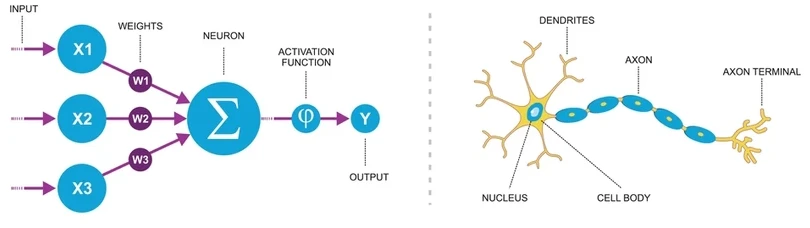

In [2]:
Image(filename='local/imgs/perceptron.webp')

As the diagram states, $x_i$ corresponds to an input variable. The whole set of input variables is typically expressed as a vector ${\bf{x}}=\{x_1,x_2,\cdots,x_d\}$.

Each $w_i$ is a real constant or weight that determines the contribution of the input $x_i$ to the perceptron's output, and $\phi$ is the activation function. In its simplest form, the activation function is just the sign function, so that the output of the perceptron would be:

$$y = \left\{
                \begin{array}{ll}
                  1\;\;\;{\rm{if}}\;\;\;w_0  + w_1 x_1  + w_2 x_2  +  \cdots  + w_d x_d  > 0\\
                  0\;\;{\rm{\text{other wise}}}
                \end{array}
              \right. $$
**Note** that even though there is no $w_0$ in the former figure, the bias term is always present and highly relevant. $−w_ 0$ is the threshold that the combination $w_1x_1 + w_2x_2 + \cdots + w_d x_d \;$ must overpass in order to get an output equal to 1. 

By assuming an additional input $x_0 = 1$, an using the sign function ($sgn$), the perceptron can alternatively be expressed as:

$$y({\bf{x}}) = sgn\left(\sum_{i=0}^{d} w_ix_i \right) = sgn({\bf{w}}^T{\bf{x}})$$

where the vector ${\bf{w}}=\{w_0,w_1,w_2,\cdots,w_d\}$.

However, since the sign function is nondifferentiable and prevents the use of gradient-based optimization algorithms for model training, it must be preplaced. The first option is to use an alternative that emulates the behavior of the sign function but continuously: the sigmoid or logistic function.

$$
g(u) = \frac{\exp(u)}{1 + \exp(u)}
$$

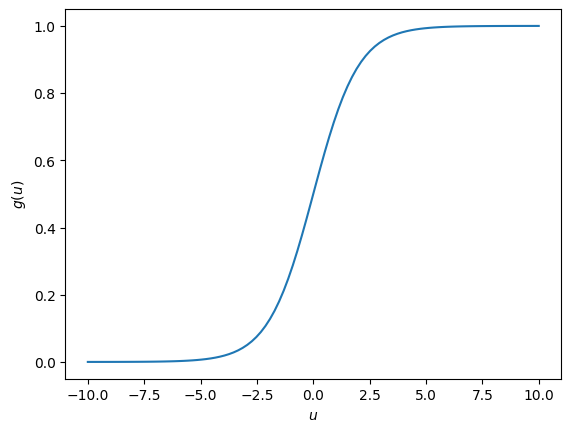

In [2]:
import numpy as np
import matplotlib.pyplot as plt
u=np.linspace(-10,10,100)
g = np.exp(u)/(1 + np.exp(u))
plt.plot(u,g)
plt.xlabel('$u$')
plt.ylabel('$g(u)$')
plt.show()

So, the perceptron can be mathematically expressed as:

$$y({\bf{x}})=g({\bf{w}}^T{\bf{x}}) = \frac{\exp({\bf{w}}^T{\bf{x}})}{1 + \exp({\bf{w}}^T{\bf{x}})} = \frac{1}{1+\exp(-{\bf{w}}^T{\bf{x}})}$$

and is equivalent to the model known as **Logistic Regression**.

We might know from our previous courses in statistics or classical Machine Learning, that a Logistic Regression is able to solve problems that look like:

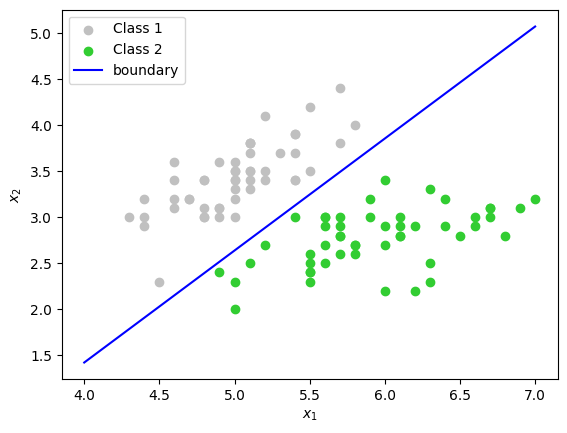

In [1]:
from local.lib.utils import plot_perceptron_frontier
plot_perceptron_frontier()

**Now let's thing about the following problem:**

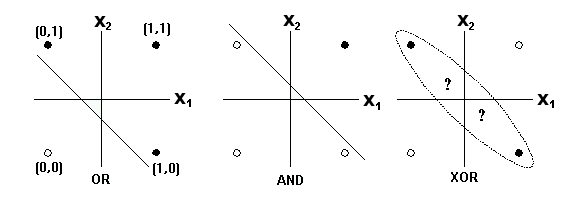

In [3]:
Image(filename='local/imgs/ORANDXOR.png', width=600)

In [3]:
class Perceptron:
    def __init__(self, learning_rate=0.1, n_epochs=50):
        self.lr = learning_rate
        self.n_epochs = n_epochs

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.errors_per_epoch = []

        for epoch in range(self.n_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                prediction = self.predict_single(xi)
                update = self.lr * (yi - prediction)
                self.weights += update * xi
                self.bias += update
                errors += int(update != 0)
            self.errors_per_epoch.append(errors)
        return self

    def predict_single(self, x):
        return 1 if np.dot(x, self.weights) + self.bias >= 0 else 0

    def predict(self, X):
        return np.array([self.predict_single(x) for x in X])


# --- AND gate dataset ---
X_and = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_and = np.array([0, 0, 0, 1])

# --- XOR gate dataset (not linearly separable) ---
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

p_and = Perceptron(learning_rate=0.1, n_epochs=20).fit(X_and, y_and)
p_xor = Perceptron(learning_rate=0.1, n_epochs=20).fit(X_xor, y_xor)

print("AND gate predictions:", p_and.predict(X_and), "| Expected:", y_and)
print("XOR gate predictions:", p_xor.predict(X_xor), "| Expected:", y_xor)
print("\nThe Perceptron FAILS on XOR — it's not linearly separable!")

AND gate predictions: [0 0 0 1] | Expected: [0 0 0 1]
XOR gate predictions: [1 1 0 0] | Expected: [0 1 1 0]

The Perceptron FAILS on XOR — it's not linearly separable!


<span style="color:red">**One single perceptron is not able to solve the problem!**</span>  

But we know that XOR can be reconstructed by using two AND and one OR functions

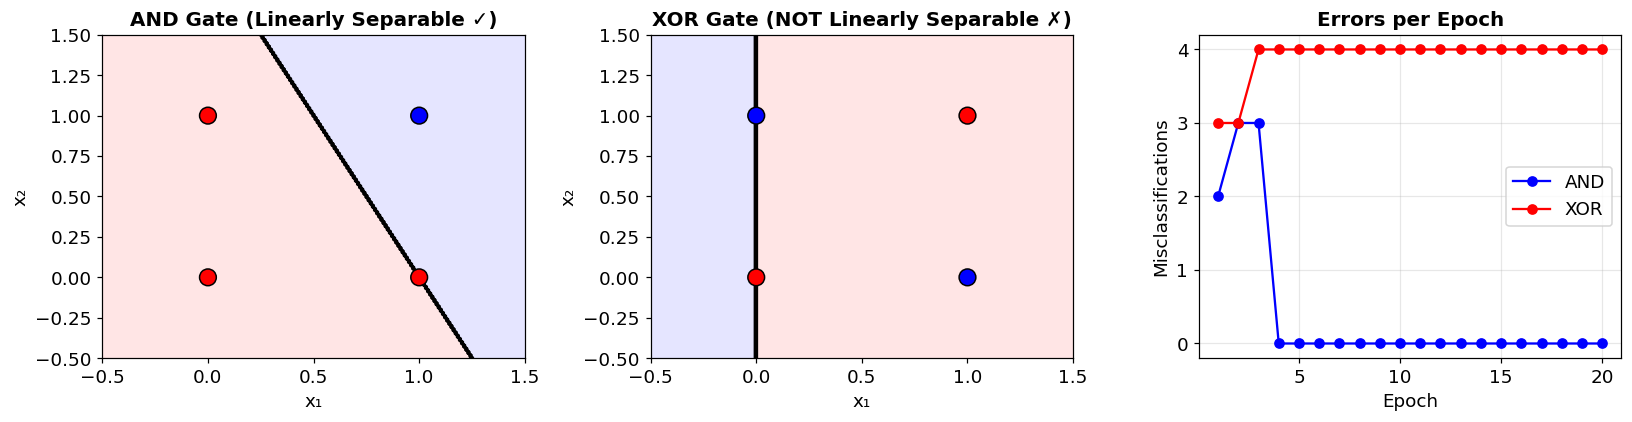

In [4]:
from local.lib.utils import plot_decision_boundary
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_decision_boundary(p_and, X_and, y_and, "AND Gate (Linearly Separable ✓)", axes[0])
plot_decision_boundary(p_xor, X_xor, y_xor, "XOR Gate (NOT Linearly Separable ✗)", axes[1])

axes[2].plot(range(1, len(p_and.errors_per_epoch)+1), p_and.errors_per_epoch, 'b-o', label='AND')
axes[2].plot(range(1, len(p_xor.errors_per_epoch)+1), p_xor.errors_per_epoch, 'r-o', label='XOR')
axes[2].set_title('Errors per Epoch', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Misclassifications')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

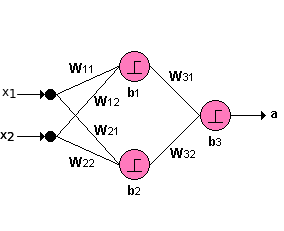

In [7]:
Image(filename='local/imgs/XOR.png', width=300)

In [5]:
from local.lib.utils import MLP
mlp = MLP(hidden_size=4, lr=1.0, n_epochs=10000).fit(X_xor, y_xor)
print("XOR predictions (MLP):", mlp.predict(X_xor), "| Expected:", y_xor)
print("MLP successfully solves XOR! ✓")

XOR predictions (MLP): [0 1 1 0] | Expected: [0 1 1 0]
MLP successfully solves XOR! ✓


<span style="color:blue">**This is a neural network!**</span> 

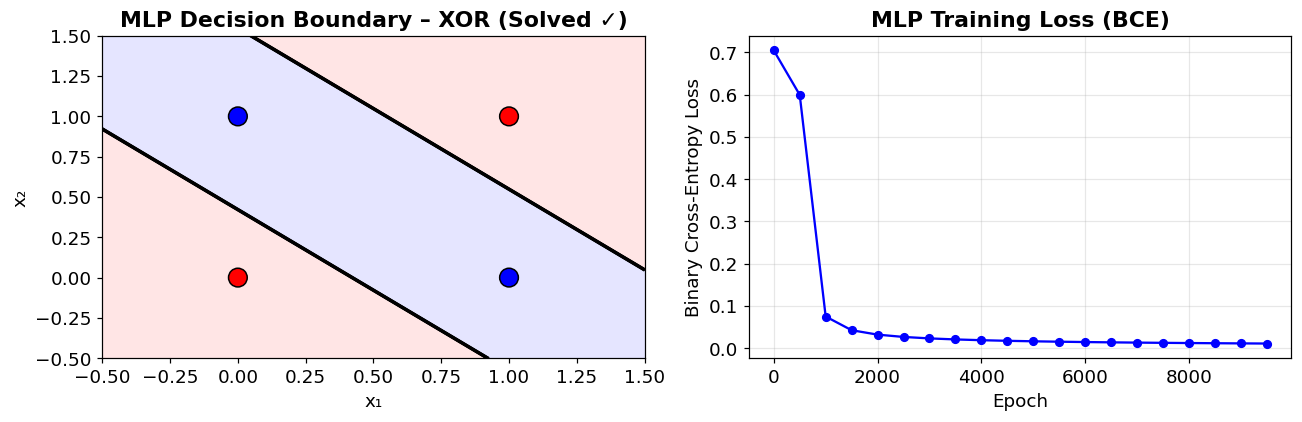

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA','#AAAAFF']))
axes[0].contour(xx, yy, Z, colors='k', linewidths=1.5)
colors = ['red' if label == 0 else 'blue' for label in y_xor]
axes[0].scatter(X_xor[:,0], X_xor[:,1], c=colors, s=150, zorder=5, edgecolors='k')
axes[0].set_title('MLP Decision Boundary – XOR (Solved ✓)', fontweight='bold')
axes[0].set_xlabel('x₁'); axes[0].set_ylabel('x₂')

# Training loss
axes[1].plot(range(0, 10000, 500), mlp.losses, 'b-o', markersize=5)
axes[1].set_title('MLP Training Loss (BCE)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Binary Cross-Entropy Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.2 Multi-layer perceptron (MLP)

In order to solve more complex problems, several perceptrons can be used together, forming what is called a multi-layer perceptron.

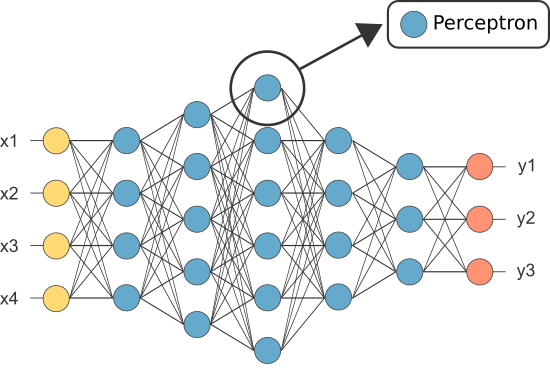

In [5]:
Image(filename='local/imgs/MLP_.png', width=600)

The output $k$ of an MLP with one input layer and one hidden layer can be expressed as:

$$
\hat{y}_{jk}(\textcolor{teal}{{\bf{x}}_j},\textcolor{blue}{{\bf{w}}}) = \sigma\left( \sum_{l=1}^{M_1} \textcolor{blue}{w_{kl}^{(2)}} h \left( \sum_{i=1}^{d} \textcolor{blue}{w_{li}^{(1)}} \textcolor{teal}{x_{ji}} + \textcolor{blue}{w_{l0}^{(1)}} \right) + \textcolor{blue}{w_{k0}^{(2)}}\right) 
$$

where $\sigma$ and $h$ are the activation functions for the output and hidden layers, respectively. Placing a sample $\textcolor{teal}{{\bf{x}}_j}$ at the input of the network and propagating its value through all the neurons and layers until getting the output $\hat{y}_{jk}(\textcolor{teal}{{\bf{x}}_j},\textcolor{blue}{{\bf{w}}})$ is called the **forward pass**.

## 1.3 Training of Artificial Neural Networks

The training phase of an Artificial Neural Network is the process required to adjust the set of weights $\textcolor{blue}{{\bf{w}}}$, which corresponds to the model's parameters, so that the network can perform the task it is intended to do.

In order to carry out this phase, the first question we have to answer is <span style="color:blue">**What do we want the network do?**</span> 

### 1.3.1 Basic loss functions

The answer to the former question is closely related to the Machine Learning task we want to tackle. It is a subject related to the shape and the values the network's output can take.

The **loss function** (also called cost or objective function) measures how far off the network's predictions are from the true labels. The choice depends on the task.

#### 1.3.1.1 Mean Squared Error (MSE) — Regression

$$\mathcal{L}_{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- Penalizes large errors more (squared term)
- Sensitive to **outliers**
- Output activation: **linear** (no activation)

#### 1.3.1.2 Binary Cross-Entropy — Binary Classification

$$\mathcal{L}_{BCE} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \right]$$

- $\hat{y}_i \in (0,1)$ — output activation: **sigmoid**
- Heavily penalizes **confident wrong predictions**

#### 1.3.1.3 Categorical Cross-Entropy — Multi-Class Classification

$$\mathcal{L}_{CCE} = -\frac{1}{n} \sum_{i=1}^{n} \sum_{c=1}^{C} y_{i,c} \log(\hat{p}_{i,c})$$

- $\hat{p}_{i,c}$ from **softmax** output
- Generalizes BCE to $C > 2$ classes

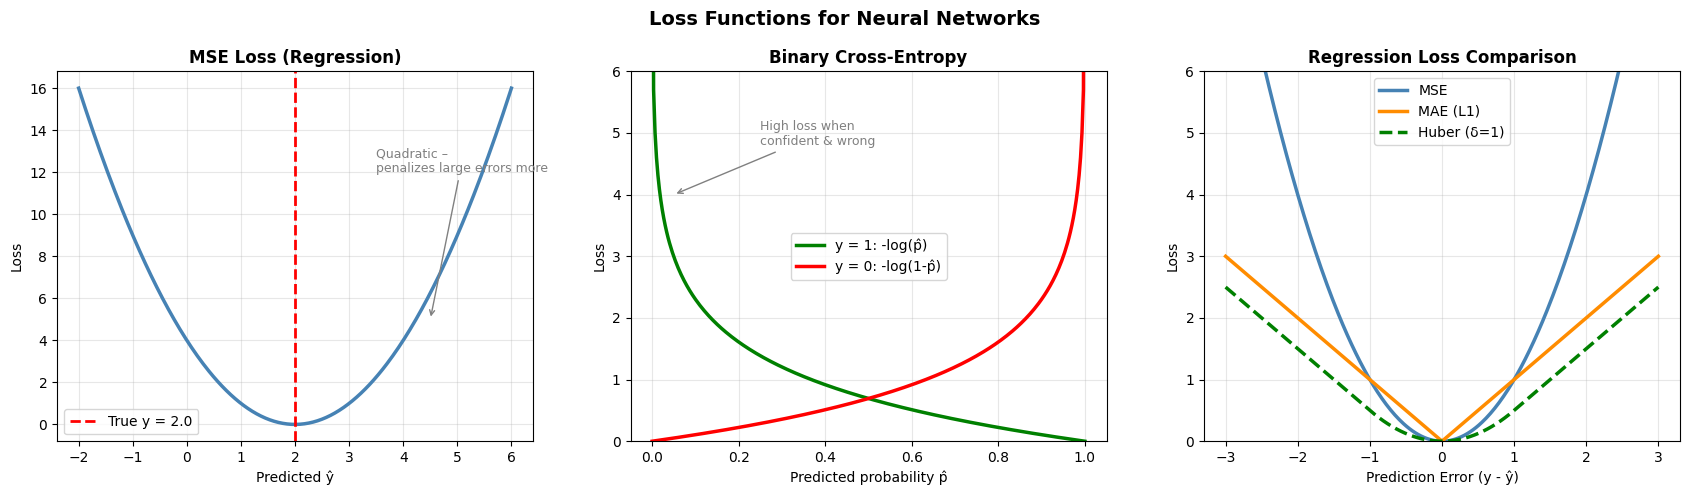

In [1]:
from local.lib.utils import plot_losses
plot_losses()

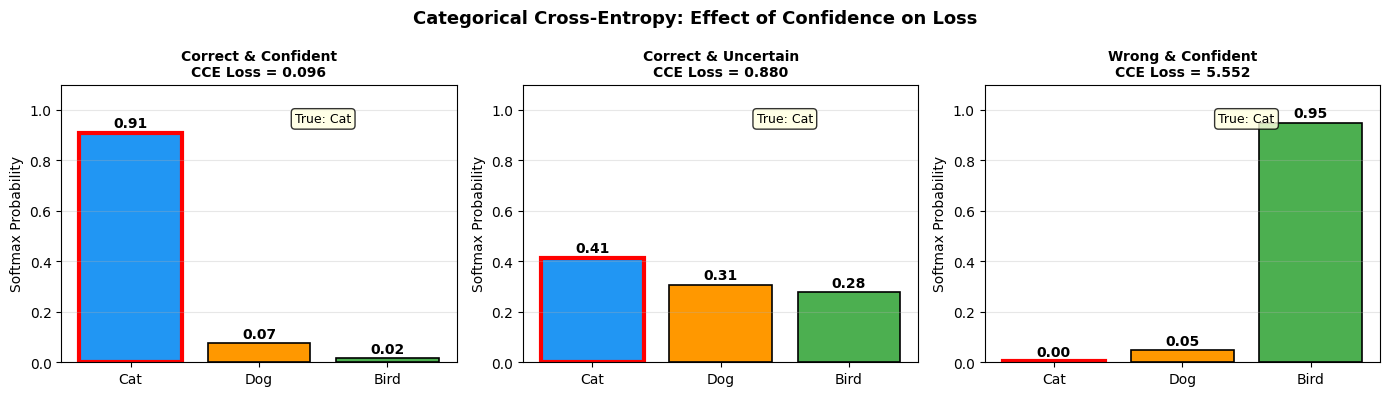

In [2]:
from local.lib.utils import plot_cce
plot_cce()

### 1.3.2 What is behind Neural Network Training

In a typicall ML problem you are given a dataset $\mathcal{D}=\{({\bf{x}}_j,y_j)\}_{j=1}^{N_s}$, where $N_s$ stands for Number of Samples. ${\bf{x}}_j$ is a vector of inputs and $y_j$ is its corresponding output target.

Let's assume we are facing a regression problem using a **Perceptron**, so the loss function looks like:

$$J({\bf{w}})=\frac{1}{N_s}\sum_{j=1}^{N_s} ({\bf{w}}^\top{\bf{x}}_j  - y_j)^2$$

The aim of the training is to find the value of the weight vector ${\bf{w}}$ that minimizes $J({\bf{w}})$. Therefore, training the model corresponds to a mathematical **optimization** problem, where the analytical function to be optimized is known. 

#### 1.3.2.1 Gradient Descent

The training of the perceptron can be carried out using the **Gradient Descent** algorithm, which is based on the following rule for iteratively update the weitghs of the perceptron using some criterion $J$:

$${\bf{w}}(\tau) = {\bf{w}}(\tau-1) - \eta\nabla J({\bf{w}})$$

$$w_i(\tau) = w_i(\tau-1) - \frac{\eta}{N_s}\sum_{j=1}^{N_s} ({\bf{w}}^\top{\bf{x}}_j - y_j)x_{ji}$$

where $\eta$ is the learning rate and $x_{ji}$ is the $i$-th input variable of the $j$-th training sample. 

<span style="color:blue">**GD was the algorithm we used before in the first two examples.**</span>

#### 1.3.2.2 Backpropagation algorithm

The Backpropagation algorithm is the application of the Gradient Descent algorithm to the neural network. The main difference with respect to the former case, is the fact that for the training of the most inner weights (all the weights in the hidden layers), the derivatives require the application of the **chain rule**.

Lets define some intermediate variables during the forward running of the network:
 
$$
 a_{jl} = \sum_{i=0}^{d} \textcolor{blue}{w_{li}^{(1)}} \textcolor{teal}{x_{ji}}, \;\; z_{jl} = h(a_{jl})
$$

$$
 a_{jk} = \sum_{l=0}^{M_1} \textcolor{blue}{w_{kl}^{(2)}} z_{jl}, \;\; \hat{y}_{jk} = \sigma(a_{jk})
$$

The gradients for the gradient descent algorithm in the output layer can be calculated as:

$$\frac{\partial J}{\partial w_{kl}^{(2)}} = \frac{\partial J}{\partial y_k}\frac{d \sigma}{d a_{k}} \frac{\partial a_{k}}{\partial \textcolor{blue}{w_{kl}^{(2)}}}$$

$$\frac{\partial J}{\partial \textcolor{blue}{w_{kl}^{(2)}}} = \frac{1}{N_s}\sum_{j=1}^{Ns} (\hat{y}_{jk}-y_{jk})\dot{\sigma}(a_{jk}) z_{jl}$$

For the hidden layer, the gradient can be calculated as:

$$\frac{\partial J}{\partial \textcolor{blue}{w_{li}^{(1)}}} = \frac{1}{Ns}\sum_{j=1}^{Ns}\sum_{k=1}^{K}(\hat{y}_{jk}-y_{jk})\dot{\sigma}(a_{jk})\frac{\partial a_{jk}}{z_l}\frac{\partial z_{jl}}{\textcolor{blue}{w_{li}^{(1)}}}$$

$$\frac{\partial J}{\partial \textcolor{blue}{w_{li}^{(1)}}} = \frac{1}{Ns}\sum_{j=1}^{Ns}\sum_{k=1}^{K}(\hat{y}_{jk}-y_{jk})\dot{\sigma}(a_{jk})\textcolor{blue}{w_{kl}^{(2)}}\dot{h}(a_{jl})\textcolor{teal}{x_{ji}}$$

The gradients can be easily extended to more layers because they follow the same formulation.

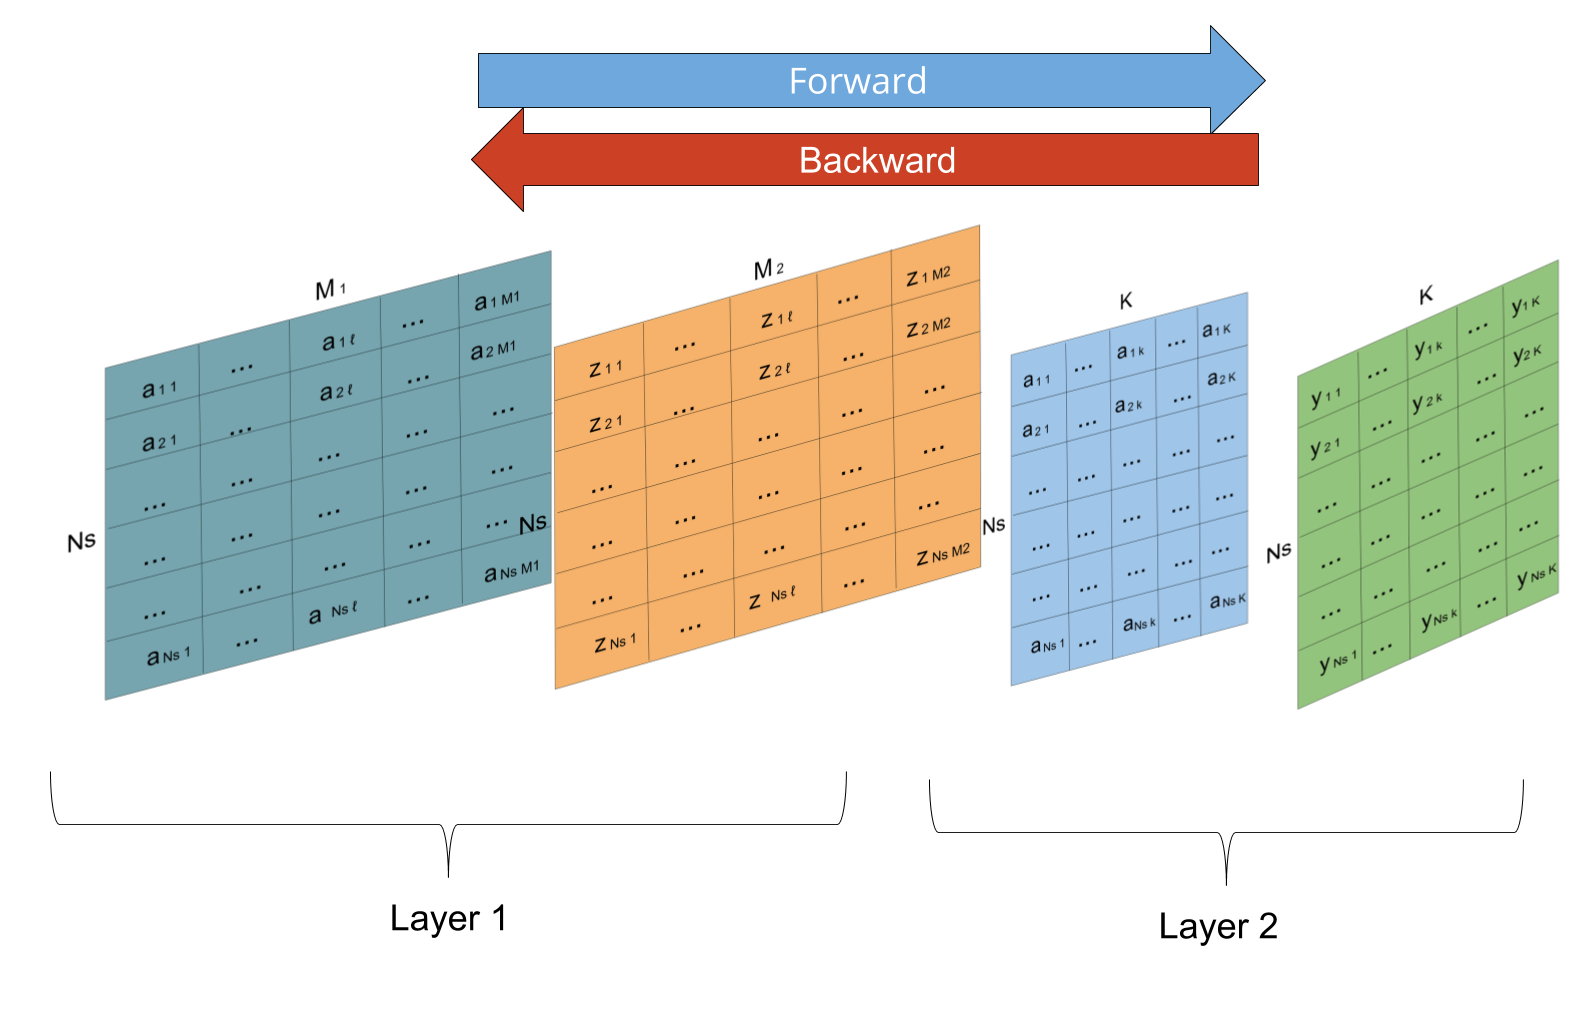

In [6]:
Image(filename='local/imgs/ForwardBackward.png')

The training that acumulates the errors from all the training samples before carrying out the update of the network weights is called **Batch training**. Unfortunately, if the number of training samples is very large, the running of every iteration becomes intratale, because both the amount of calculations (CPU time) and amount of memory (RAM) required to perform matrix multiplications and to save partial results. But the real handicap is the batch gradient trajectory land you in a bad spot (**saddle point**).

#### 1.3.2.3 GD Variants

| Variant | Batch Size | Pros | Cons |
|---------|-----------|------|------|
| **Batch GD** | Full dataset | Stable gradients | Slow; requires all data in memory |
| **Stochastic GD (SGD)** | 1 sample | Fast updates | Noisy; may not converge smoothly |
| **Mini-Batch GD** | 32–512 samples | Best of both worlds | Requires tuning batch size |

#### 1.3.2.4 Hardware Requirements & the Need for Mini-Batches

Modern deep learning relies on **GPUs** (and TPUs) for training:

- **GPUs** have thousands of CUDA cores optimized for **parallel matrix operations** — the dominant computation in neural networks.
- **GPU memory (VRAM)** is limited (e.g., 8–80 GB). Training on the full dataset at once is infeasible for large datasets.
- **Mini-batches** allow:
  - Efficient GPU memory usage (process a small chunk at a time)
  - Parallelism within a batch via vectorized operations
  - Regularization effect from gradient noise (helps escape local minima)

> 🖥️ **Rule of thumb**: Batch size should be a power of 2 (32, 64, 128, 256) to align with GPU memory architecture. Larger batches → more stable gradients but less generalization; smaller batches → noisier but can generalize better.

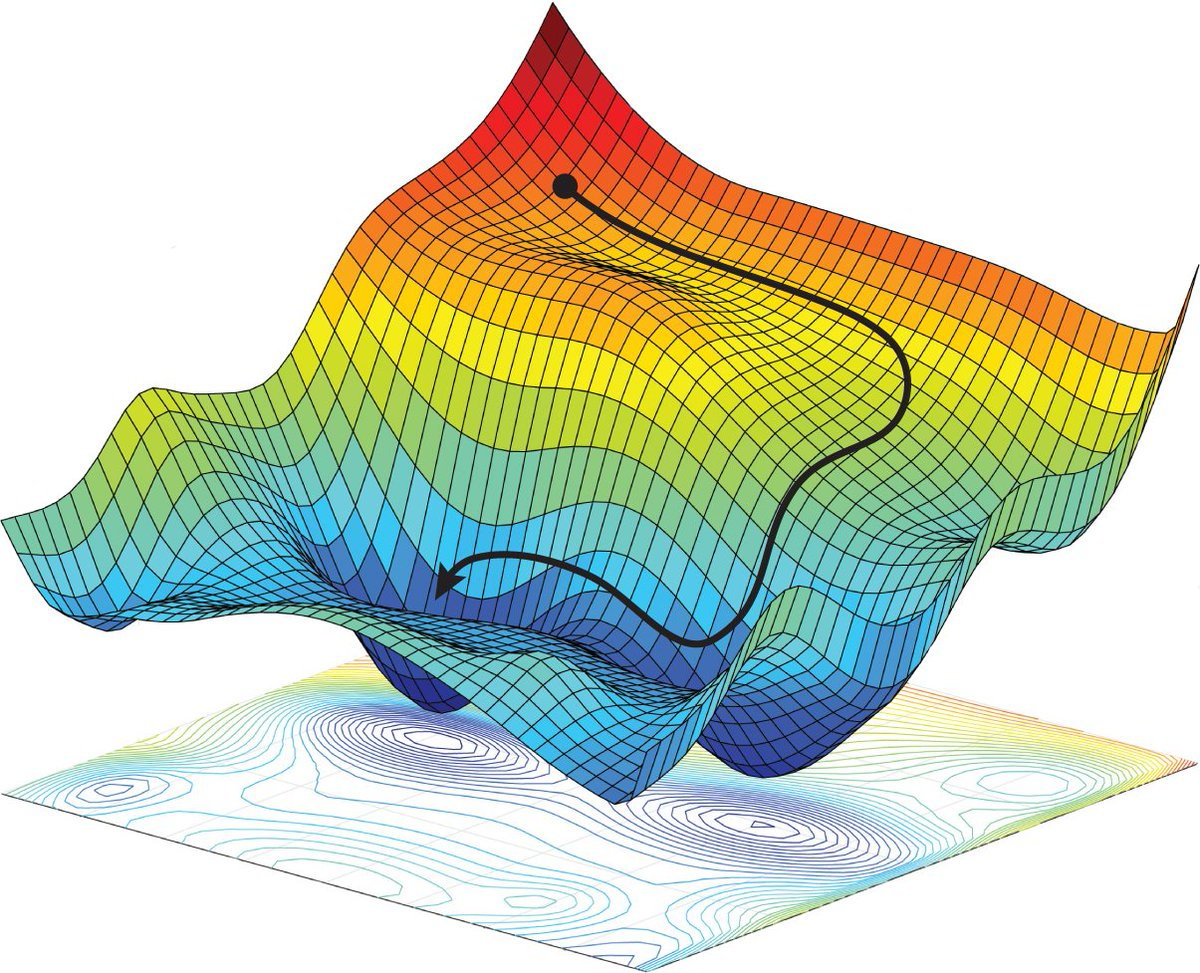

In [4]:
Image(filename='local/imgs/Optimi_surface.jpg', width=400)

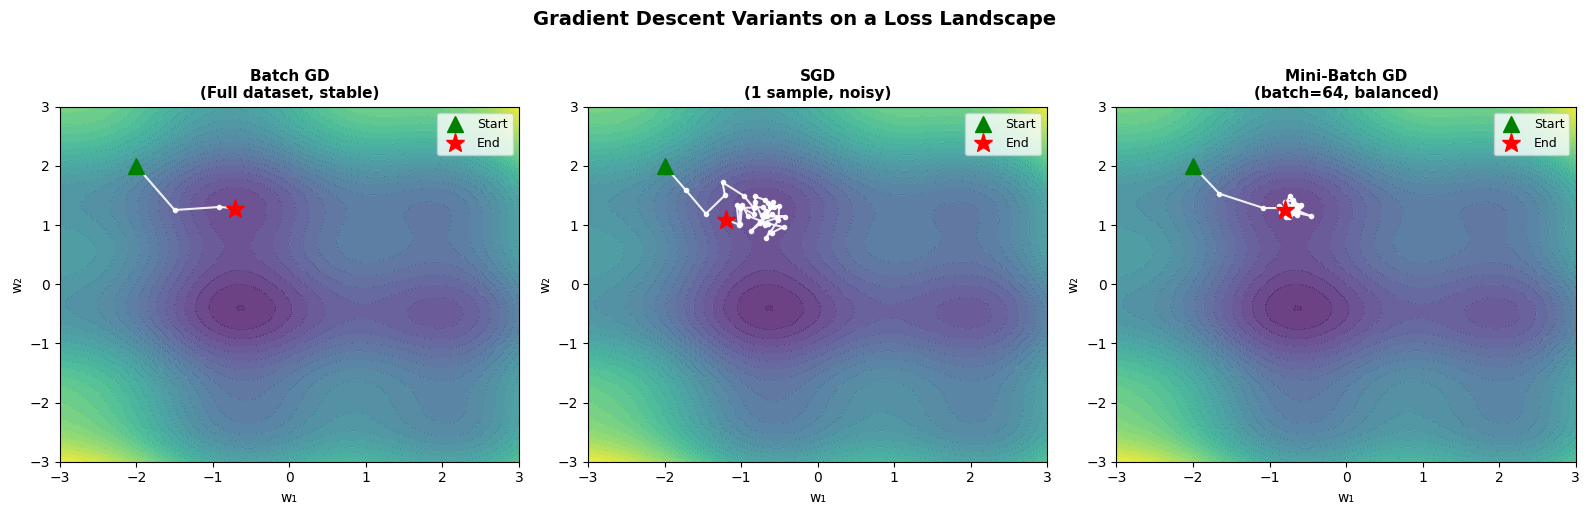

In [1]:
from local.lib.utils import plot_GD_batch
plot_GD_batch()

(1500, 2)


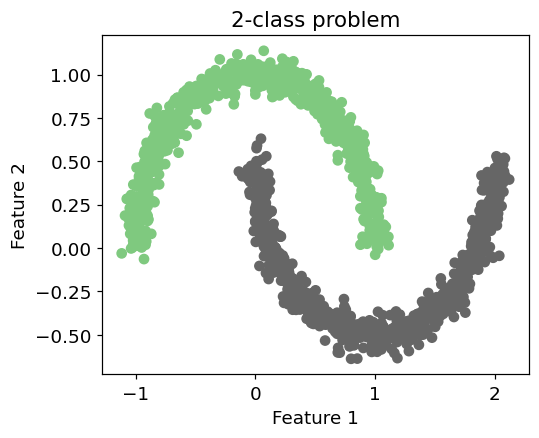

In [4]:
from sklearn import cluster, datasets
n_samples = 1500
X, y = datasets.make_moons(n_samples=n_samples, noise=.05)
print(X.shape)
plt.figure(figsize=(5, 4))
plt.title('2-class problem', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.scatter(X[:,0], X[:,1], c=y,cmap="Accent");

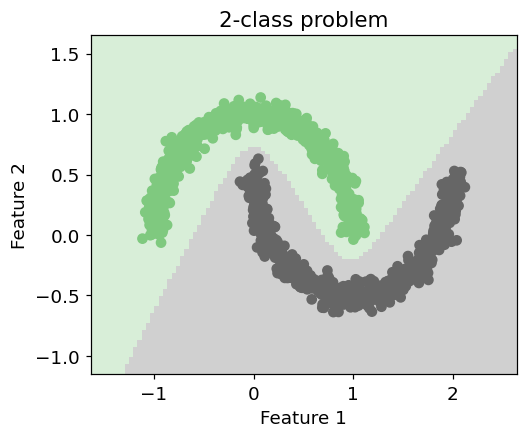

In [5]:
from local.lib.utils import mlp_2_class
mlp_2_class(X,y)

1 ok
2 ok
3 ok


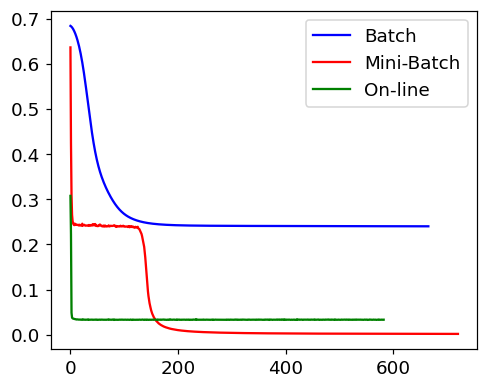

In [6]:
clf1 = MLPClassifier(activation='logistic',solver='sgd', learning_rate_init = 0.1, learning_rate = 'constant', batch_size=1500, hidden_layer_sizes=(5,), random_state=1,n_iter_no_change = 500, max_iter=2000)
clf1.fit(X, y)
print ("1 ok")
clf2 = MLPClassifier(activation='logistic',solver='sgd', learning_rate_init = 0.1, learning_rate = 'constant', batch_size=50, hidden_layer_sizes=(5,), random_state=1,n_iter_no_change =500, max_iter=2000)
clf2.fit(X, y)
print ("2 ok")
clf3 = MLPClassifier(activation='logistic',solver='sgd', learning_rate_init = 0.1, learning_rate = 'constant', batch_size=1, hidden_layer_sizes=(5,), random_state=1,n_iter_no_change =500, max_iter=2000)
clf3.fit(X, y)
print ("3 ok")
plt.figure(figsize=(5, 4))
plt.plot(clf1.loss_curve_,color='b',label='Batch')
plt.plot(clf2.loss_curve_,color='r',label='Mini-Batch')
plt.plot(clf3.loss_curve_,color='g',label='On-line')
plt.legend()
plt.show()

**Now with a larger learning rate**

1 ok
2 ok
3 ok


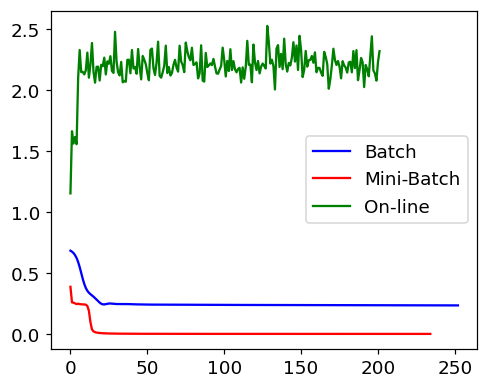

In [7]:
clf1 = MLPClassifier(activation='logistic',solver='sgd', learning_rate_init = 1, learning_rate = 'constant', batch_size=1500, hidden_layer_sizes=(5,), random_state=1,max_iter=2000, n_iter_no_change=200)
clf1.fit(X, y)
print ("1 ok")
clf2 = MLPClassifier(activation='logistic',solver='sgd', learning_rate_init = 1, learning_rate = 'constant', batch_size=50, hidden_layer_sizes=(5,), random_state=1, max_iter=2000, n_iter_no_change=200)
clf2.fit(X, y)
print ("2 ok")
clf3 = MLPClassifier(activation='logistic',solver='sgd', learning_rate_init = 1, learning_rate = 'constant', batch_size=1, hidden_layer_sizes=(5,), random_state=1,max_iter=2000, n_iter_no_change=200)
clf3.fit(X, y)
print ("3 ok")
plt.figure(figsize=(5, 4))
plt.plot(clf1.loss_curve_,color='b',label='Batch')
plt.plot(clf2.loss_curve_,color='r',label='Mini-Batch')
plt.plot(clf3.loss_curve_,color='g',label='On-line')
plt.legend()
plt.show()

## 1.4 Activation Functions

Activation functions introduce **non-linearity** — without them, a deep network collapses to a single linear transformation.

| Function | Formula | Range | Common Use |
|----------|---------|-------|------------|
| **Sigmoid** | $\sigma(z) = \frac{1}{1+e^{-z}}$ | $(0,1)$ | Output (binary classification) |
| **Tanh** | $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $(-1,1)$ | Hidden layers (older models) |
| **ReLU** | $\max(0, z)$ | $[0, \infty)$ | Hidden layers (default choice) |
| **Leaky ReLU** | $\max(0.01z, z)$ | $(-\infty, \infty)$ | Fixes dying ReLU |
| **Softmax** | $\frac{e^{z_i}}{\sum_j e^{z_j}}$ | $(0,1)$ | Output (multi-class) |

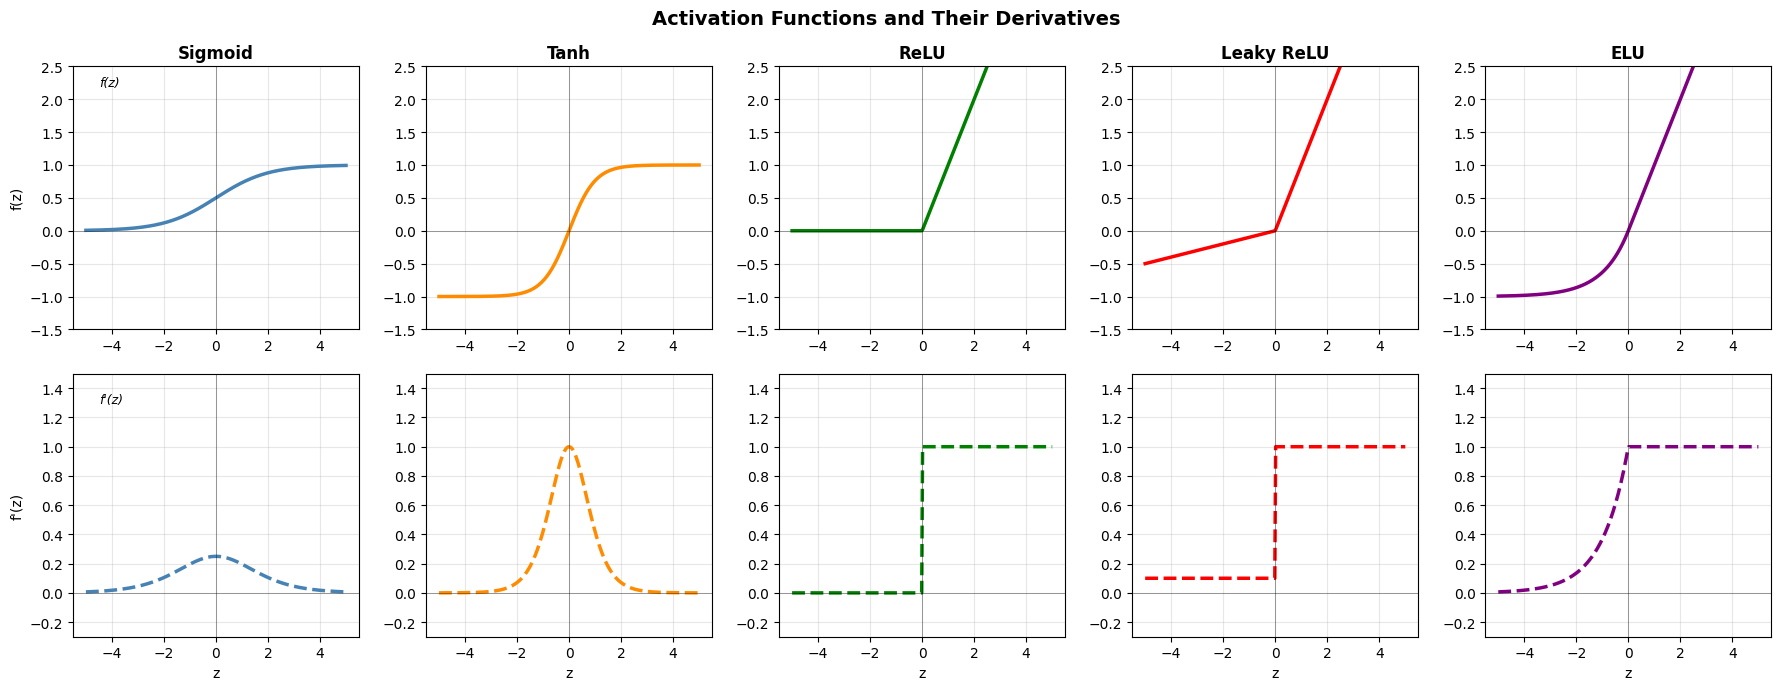

In [1]:
from local.lib.utils import plot_activation_functions
plot_activation_functions()

### 1.4.1 The Vanishing Gradient Problem

During backpropagation, gradients are multiplied through many layers:

$$\frac{\partial L}{\partial \mathbf{W}^{(1)}} = \frac{\partial L}{\partial \mathbf{z}^{(N)}} \cdot \prod_{l=2}^{N} \frac{\partial \mathbf{z}^{(l)}}{\partial \mathbf{z}^{(l-1)}}$$

With **Sigmoid/Tanh**, derivatives are always $< 1$ (max ~0.25 for sigmoid). Multiplied across many layers:

$$0.25^{10} \approx 10^{-6} \quad \text{(virtually zero!)}$$

Early layers **stop learning** because their gradients vanish.

**How to Prevent Vanishing Gradients**

| Solution | How it helps |
|----------|-------------|
| **ReLU / Leaky ReLU** | Derivative is 1 for positive inputs — gradient passes through unchanged |
| **Batch Normalization** | Normalizes layer inputs, keeping activations in healthy range |
| **Residual Connections (ResNets)** | Skip connections provide gradient highways: $\mathbf{z}^{(l+2)} = f(\mathbf{a}^{(l+1)}) + \mathbf{z}^{(l)}$ |
| **Careful Weight Init** | Prevents activations from exploding or collapsing (see next section) |
| **Gradient Clipping** | Caps gradient norm to prevent explosion (complementary issue) |

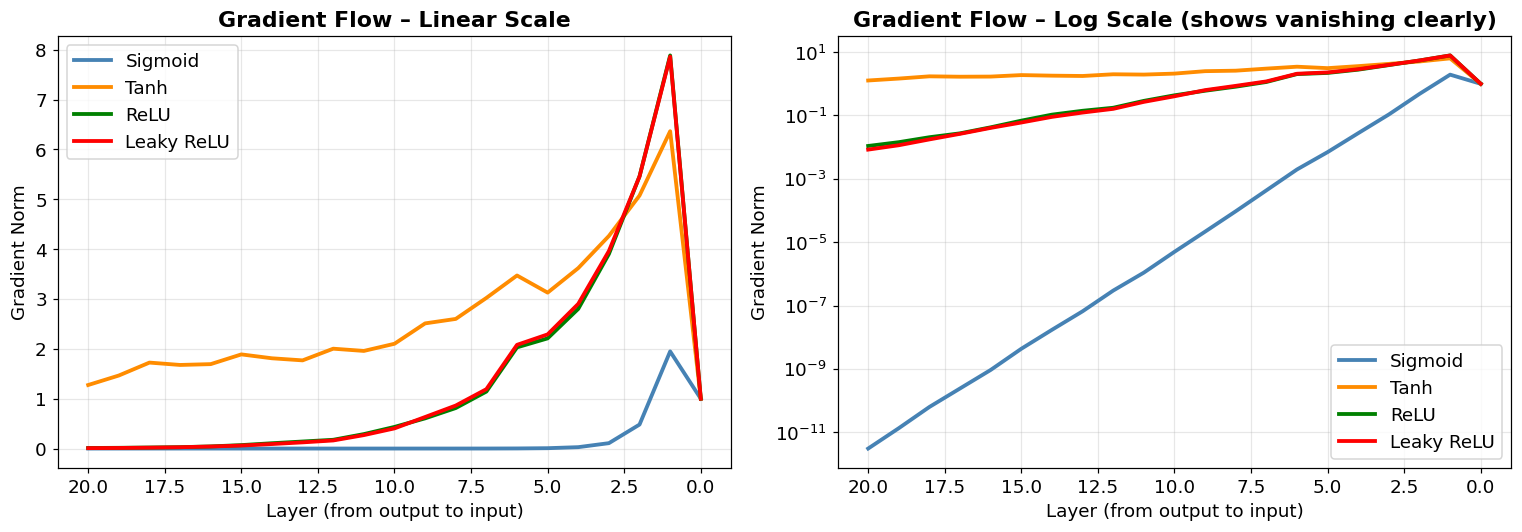

Sigmoid and Tanh gradients vanish to near-zero in early layers.
ReLU/Leaky ReLU maintain gradient flow throughout the network.


In [3]:
from local.lib.utils import simulate_gradient_flow
n_layers = 20
acts = {'Sigmoid': 'steelblue', 'Tanh': 'darkorange', 'ReLU': 'green', 'Leaky ReLU': 'red'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, color in acts.items():
    norms = simulate_gradient_flow(name.lower().replace(' ', '_'), n_layers)
    axes[0].plot(range(n_layers+1), norms, color=color, linewidth=2.5, label=name)
    axes[1].semilogy(range(n_layers+1), [max(n, 1e-20) for n in norms], color=color, linewidth=2.5, label=name)

for ax in axes:
    ax.set_xlabel('Layer (from output to input)', fontsize=12)
    ax.set_ylabel('Gradient Norm')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

axes[0].set_title('Gradient Flow – Linear Scale', fontweight='bold')
axes[1].set_title('Gradient Flow – Log Scale (shows vanishing clearly)', fontweight='bold')

plt.tight_layout()
plt.show()
print("Sigmoid and Tanh gradients vanish to near-zero in early layers.")
print("ReLU/Leaky ReLU maintain gradient flow throughout the network.")

### 1.4.2 Weight Initialization

Proper initialization is crucial. Poor initialization causes:
- **Too small weights** → activations collapse to zero → gradients vanish
- **Too large weights** → activations saturate → gradients vanish (sigmoid/tanh) or explode

**Common Strategies**

| Method | Formula | Best With |
|--------|---------|----------|
| **Zero Init** | $W = 0$ | ❌ Never (symmetry breaking problem) |
| **Random (naive)** | $W \sim \mathcal{N}(0, 0.01)$ | Small networks only |
| **Xavier / Glorot** | $W \sim \mathcal{N}\left(0, \frac{2}{n_{in}+n_{out}}\right)$ | Sigmoid / Tanh |
| **He / Kaiming** | $W \sim \mathcal{N}\left(0, \frac{2}{n_{in}}\right)$ | ReLU and variants |

The key insight: keep the **variance of activations constant** across layers.

When information flows forward through a network, each layer's output becomes the next layer's input. If the variance grows or shrinks at each step, you get compounding problems:

- **If variance shrinks (too small)**
Activations collapse toward zero as they pass through layers. By the time you reach deep layers, every neuron is outputting near-zero values regardless of the input — the network has effectively lost the signal. During backprop, gradients also vanish for the same reason.

- **If variance grows (too large)**
Activations explode toward very large values. For bounded activations like sigmoid and tanh, large inputs push neurons into their saturation zones (the flat parts of the curve), where derivatives are near zero — and again, gradients vanish. For unbounded activations like ReLU, exploding activations can cause numerical instability.

- **The ideal: stable variance**
If each layer outputs activations with roughly the same variance as its inputs, the signal neither dies out nor explodes as it travels through 10, 50, or 100 layers. This keeps:

Forward pass: meaningful, informative activations reaching the output
Backward pass: gradients of usable magnitude reaching early layers, so they actually learn

<span style="color:blue">**Symmetry breaking problem**</span>: When all weights are initialized to the same value (especially zero), every neuron in a layer computes the exact same function — they receive the same inputs, produce the same output, and crucially, receive the same gradient during backpropagation.
This means every neuron updates identically on every step. No matter how long you train, all neurons in a layer remain identical to each other. A hidden layer of 128 neurons effectively behaves like a layer of 1 neuron — you've lost all the representational capacity you paid for.

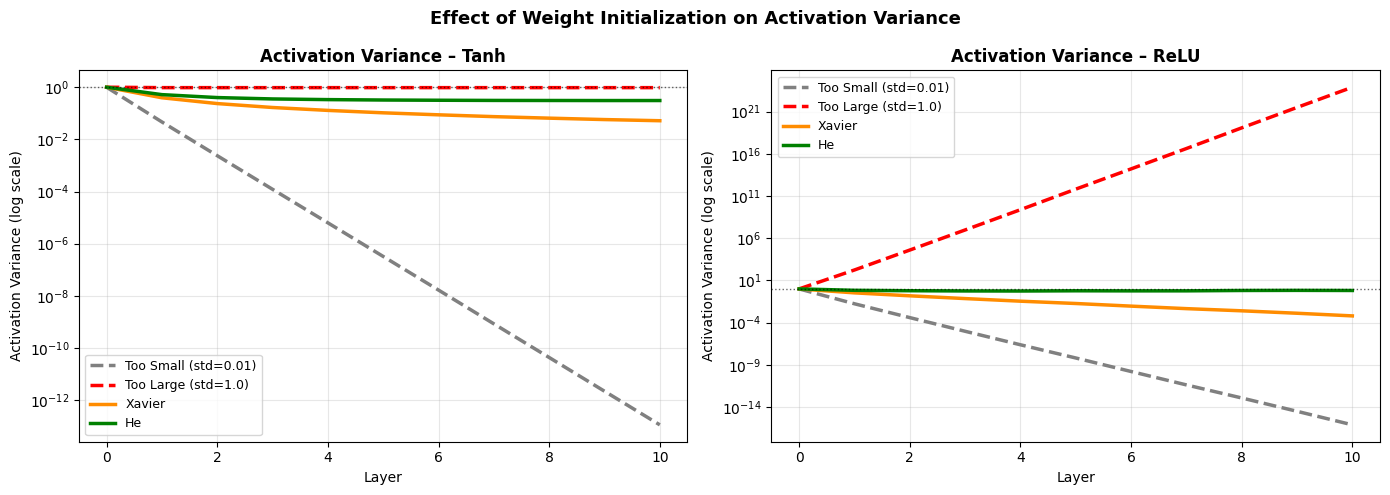

Xavier is best for Tanh; He initialization is best for ReLU.


In [1]:
from local.lib.utils import plot_weight_init_effects
plot_weight_init_effects()

## 1.5 Drawbacks of the classical approaches

**Inflexibility**

* Classical approaches require an entire formulation if you want to change the loss function or test a slightly different architecture.
* A new arquitecture require the calculation of all the re-estimation formulas, without taking advantage of symbolic derivative tools.
* Some classical frameworks support the regularization of ANN, but they do not include the most recent advances.
* Many new activation functions are not available and can not be selected at will.
* Classical frameworks do not take advantage of parallelism.
* Transfer learning